## Low rank solutions
This notebook looks at the residuals $r^{(i)} = \| K^T M_\partial y - H X^{(i)} \|_F = \| \nabla \Phi (X^{(i)}) \|_F$ when increasing the rank $r$.


---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils.problem_setup import TestProblemsSetup
from algorithms.cg_solvers import DynamicalLowRankPCG, frobenius2
from algorithms.rsvd_solvers import MatrixFreeRSVD

import numpy as np
import matplotlib.pyplot as plt
from algorithms.cg_solvers_instrumented import (
    DynamicalLowRankPCGConjugacy,
    DynamicalLowRankCGShadow
)
from utils.colors import C5, LS

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15
SETUP = TestProblemsSetup(n=64)
PROBLEMS = SETUP.get_test_problems()
PROBLEM_PARAMS = SETUP.problem_params

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
from algorithms.cg_solvers_instrumented import DynamicalLowRankCGShadow

pid = 'I'
pb = PROBLEMS[pid]
rsvd = MatrixFreeRSVD(pb['V_h']); rsvd.solve(k=50, seed=SEED)
w = rsvd.weights()

solver = DynamicalLowRankCGShadow(rsvd, x_true=pb['x'])

distances, errors, tangent = [], [], []
for r in [1]:
    solver.solve(
        pb['y'], w,
        lambda_=1e-4, max_rank=r, max_iter=200, rtol=0, restart_every=None,
        seed=SEED
    )
    distances.append(solver.shadow_distance_rel.copy())
    errors.append(solver.error.copy())
    tangent.append(solver.tangent_fraction.copy())


[##############################] 200/200


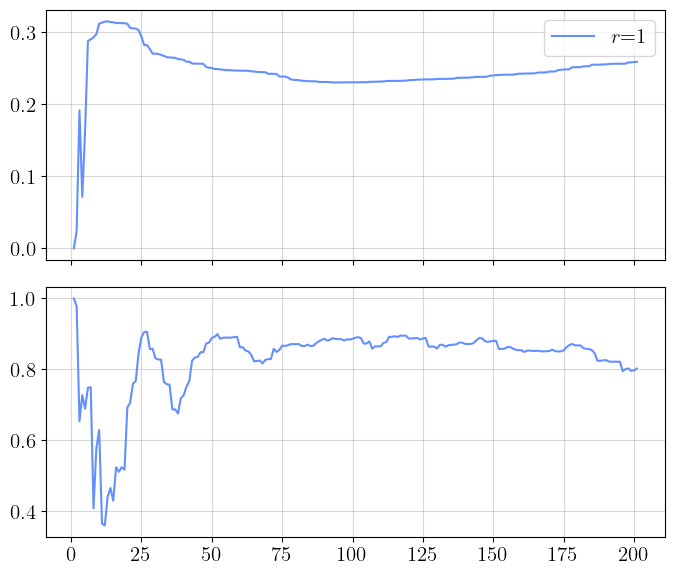

In [29]:
from utils.colors import C5, LS

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax, ax2 = axes

dist = solver.shadow_distance_rel
nd = len(dist)

labels = [f"$r$={i}" for i in [1, 2, 10]]

for i, d in enumerate(distances):
    ax.plot(np.arange(1,1+nd), d, c=C5[i], ls=LS[i], label=labels[i])
    ax2.plot(np.arange(1,1+nd), tangent[i], c=C5[i], ls=LS[i])


ax.legend()
ax.grid(True, alpha=.5)
ax2.grid(True, alpha=.5)
plt.tight_layout()
plt.show()

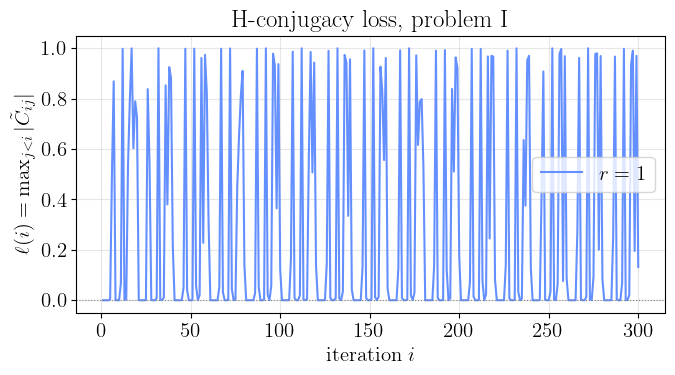

In [26]:


# Use a small mesh: instrumented solver stores HD per iteration.
SETUP_S  = TestProblemsSetup(n=32)
PROBLEMS_S = SETUP_S.get_test_problems()

pid = 'I'
pb = PROBLEMS_S[pid]
rsvd = MatrixFreeRSVD(pb['V_h']); rsvd.solve(k=50, seed=SEED)
w = rsvd.weights()

ranks    = [1]
max_iter = 300
loss_by_rank = {}

for r in ranks:
    solver = DynamicalLowRankPCGConjugacy(rsvd, pb['x'])
    solver.solve(pb['y'], w,
        lambda_=1e-4, max_iter=max_iter, max_rank=r,
        rtol=0, etol=0, seed=SEED,
        preconditioner='none', restart_every=20,
        verbose=False,
    )
    loss_by_rank[r] = np.asarray(solver.conjugacy_loss)

# Reference: plain CG (no truncation, no rank constraint)
from algorithms.cg_solvers import ConjugateGradient
# (CG keeps no instrumentation; if you want a baseline curve, instrument it
# the same way — for now we just visualize the DLR side.)

fig, ax = plt.subplots(figsize=(7, 4))

for k, r in enumerate(ranks):
    ax.plot(
        np.arange(1, 1+len(loss_by_rank[r])), loss_by_rank[r],
        color=C5[k], ls=LS[0], label=fr'$r = {r}$'
    )
ax.axhline(1e-12, ls=':', color='gray', lw=0.8)
ax.set_xlabel('iteration $i$')
ax.set_ylabel(r'$\ell(i) = \max_{j<i} |\tilde C_{ij}|$')
ax.set_title(f'H-conjugacy loss, problem {pid}')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
pid = 'I'
pb = PROBLEMS[pid]
rsvd = MatrixFreeRSVD(pb['V_h']); rsvd.solve(k=50, seed=SEED)
w = rsvd.weights()
errors, residuals = [], []

solver = DynamicalLowRankPCG(rsvd, pb['x'])
for r in r_list:
    x = solver.solve(pb['y'], w,
        lambda_=lambda_, max_iter=max_iter, max_rank=r, rtol=0, etol=0, seed=SEED,
        restart_every=10, preconditioner='none'
    )
    X = solver.vec_to_matrix(x)
    G = solver.gradient(X, pb['y'], w, lambda_**2)  # note: lambda**2 (see solve)

    residuals.append(np.sqrt(frobenius2(G)))
    errors.append(np.linalg.norm(x - pb['x']))

# Find full rank error and residual
solver_cg = ConjugateGradient(rsvd, pb['x'])
x_cg = solver_cg.solve(pb['y'], w,
    lambda_=lambda_, max_iter=max_iter, rtol=0, etol=0, seed=SEED,
)

X_cg = solver_cg.vec_to_matrix(x_cg)
G_cg = solver_cg.gradient(X_cg, pb['y'], w, lambda_**2)  # note: lambda**2 (see solve)
res_cg = np.sqrt(frobenius2(G_cg))
err_cg = np.linalg.norm(x_cg - pb['x'])


In [158]:
r_list = np.arange(1, 11)

resultsI = experiment(r_list, 'I', max_iter=10_000)
resultsII = experiment(r_list, 'II', max_iter=10_000)

[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000
[##############################] 10000/10000


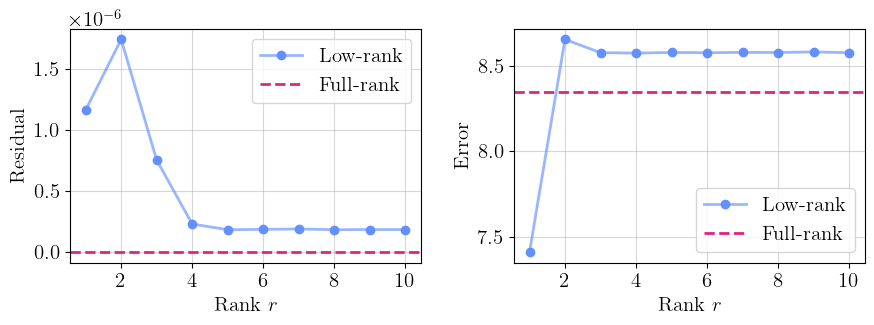

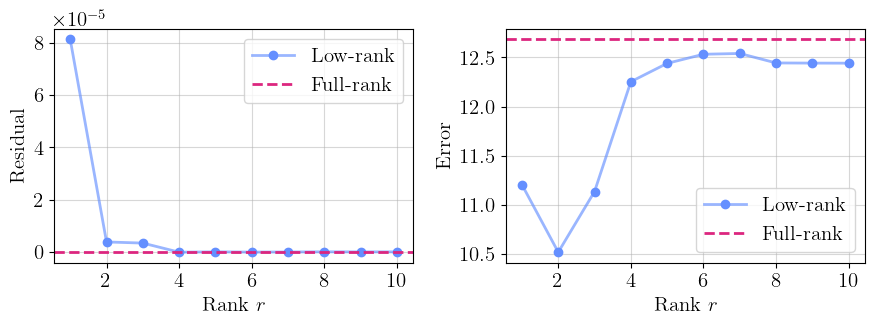

In [160]:
from matplotlib.lines import Line2D
from utils.colors import C2, M, MS
from utils.plotting import save_plot


def plot_results(results, fig_name=None):
    M = ['o', None]
    ALPHAS = [0.65, 1.0]
    LS = ['-', '--']

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    ax1, ax2 = axes
    
    # Residual plot
    ax1.plot(r_list, results['res'], c=C2[0], lw=2, alpha=.65)
    ax1.plot(r_list, results['res'], M[0], c=C2[0], lw=2)
    ax1.axhline(results['res_cg'], ls='--', c=C2[1], lw=2)

    # Error plot
    ax2.plot(r_list, results['err'], c=C2[0], lw=2, alpha=.65)
    ax2.plot(r_list, results['err'], M[0], c=C2[0], lw=2)
    ax2.axhline(results['err_cg'], ls='--', c=C2[1], lw=2)

    ax1.set_ylabel('Residual')
    ax2.set_ylabel('Error')

    labels = ['Low-rank', 'Full-rank']
    handles = []
    for i in range(2):
        legend_line = Line2D([0], [0], color=C2[i], linewidth=2.0, alpha=ALPHAS[i], linestyle=LS[i])
        legend_marker = Line2D([0], [0], color=C2[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    for ax in axes:
        ax.set_xlabel('Rank $r$')
        ax.grid(True, alpha=.5)
        ax.legend(handles=handles, labels=labels)

    plt.tight_layout()
    save_plot(fig_name)
    plt.show()


plot_results(resultsI, fig_name='low_rank_residual_I')
plot_results(resultsII, fig_name='low_rank_residual_II')
